# Gradient Boosting LambdaRank (S1 Equities)

Pooled LightGBM **LambdaRank** on `s1_engineered_features`. Relevance labels =
within-date CS quintiles of `fwd_ret_5` (0..4) on week-start rows. Early stopping
on **NDCG@5** (not RMSE).

Chronological IS → train / embargo / val → freeze HPs by val mean IC → sealed holdout.
Artifacts are distinct from `training_gbm_rmse.ipynb` so the RMSE baseline is not overwritten.


## 0. Imports & Config


In [1]:
import os
import sys
import time
import warnings

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import uniform
from sklearn.model_selection import ParameterSampler

warnings.filterwarnings("ignore")

ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from models.s1_equities.training_common import (
    LABEL_COL,
    RELEVANCE_COL,
    add_relevance_quintiles,
    attach_scores,
    chronological_is_split,
    date_ic_series,
    default_paths,
    drop_nonfinite_labels,
    group_sizes,
    ic_segment_table,
    mean_date_ic,
    prepare_s1_week_panel,
)

PATHS = default_paths(ROOT)
FEATURES_PATH = PATHS["features"]
TRAIN_PANEL_PATH = PATHS["train_panel"]
MODEL_DIR = PATHS["model_dir"]
TEARSHEET_DIR = PATHS["tearsheet_dir"]

PRED_PATH = os.path.join(
    MODEL_DIR, "s1_lgbm_lambdarank_is_predictions.parquet"
)
IS_MODEL_PATH = os.path.join(MODEL_DIR, "s1_lgbm_lambdarank_is.txt")
IS_JOBLIB_PATH = os.path.join(MODEL_DIR, "s1_lgbm_lambdarank_is.joblib")
PROD_MODEL_PATH = os.path.join(MODEL_DIR, "s1_lgbm_lambdarank_production.txt")
TEARSHEET_PATH = os.path.join(TEARSHEET_DIR, "s1_lgbm_lambdarank_training.pdf")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(TEARSHEET_DIR, exist_ok=True)

VAL_FRAC = 0.15
EMBARGO_WEEKS = 1

N_RANDOM_TRIALS = 100
N_ESTIMATORS_CAP = 2000
EARLY_STOPPING_ROUNDS = 70
RANDOM_SEED = 42
ROLLING_IC_WEEKS = 26

# Slightly shallower than RMSE notebook; regularization-leaning
PARAM_DISTRIBUTIONS = {
    "max_depth": [3, 4, 5, 6],
    "num_leaves": [15, 20, 31, 63],
    "learning_rate": [0.01, 0.02, 0.03],
    "min_child_samples": [20, 50, 100, 200, 350],
    "subsample": uniform(0.6, 0.3),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_lambda": [0.0, 0.1, 1.0, 5.0],
}

print(f"ROOT={ROOT}")
print(f"FEATURES_PATH={FEATURES_PATH}")
print(f"IS_MODEL_PATH={IS_MODEL_PATH}")
print(f"lightgbm={lgb.__version__}")

ROOT=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio
FEATURES_PATH=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s1_equities\s1_engineered_features.parquet
IS_MODEL_PATH=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_lgbm_lambdarank_is.txt
lightgbm=4.6.0


## 1. Loading the Dataset


In [2]:
df, FEATURE_COLS, prices = prepare_s1_week_panel(FEATURES_PATH, TRAIN_PANEL_PATH)
print(f"Week-start rows: {df.shape}  unique weeks={df['date'].nunique():,}")
print(f"FEATURE_COLS ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(
    f"IS weeks={df.loc[df['is_research_is'], 'date'].nunique():,}  "
    f"holdout weeks={df.loc[~df['is_research_is'], 'date'].nunique():,}"
)
df.head()

Week-start rows: (85279, 39)  unique weeks=865
FEATURE_COLS (27): ['raw_momentum_252_5', 'obv_mom_soft_126_21_20', 'smart_residual_mom_189_42', 'rel_downside_beta_252', 'rel_upside_beta_63', 'smart_beta_smb_84', 'smart_beta_hml_252', 'downside_beta_42', 'smart_beta_mom_126', 'upside_beta_42', 'near_52w_ratio_252_raw', 'size_mom_126', 'val_roc_pb_252', 'val_roc_pe_252', 'earnings_yield', 'log_mcap', 'val_mom_dist_252_21', 'val_mom_resid_126_252_10', 'gross_profitability', 'filing_clock_expected_until', 'short_flow_ratio', 'market_corr', 'beta_mkt_interact', 'abnormal_volume', 'gdelt_tone_x_attention_21', 'gdelt_attention_5', 'gdelt_abnormal_attention_5_60']
IS weeks=422  holdout weeks=443


,date,ticker,feature_date,open,high,low,close,volume,fwd_ret_1,fwd_ret_5,...,gross_profitability,filing_clock_expected_until,short_flow_ratio,market_corr,beta_mkt_interact,abnormal_volume,gdelt_tone_x_attention_21,gdelt_attention_5,gdelt_abnormal_attention_5_60,is_research_is
0,2010-01-05,AAPL,2010-01-04,6.424143,6.421146,6.357683,6.406478,493729600.0,-0.001025,-0.025210,...,NaN,27.0,0.439729,NaN,NaN,NaN,NaN,NaN,NaN,False
1,2010-01-05,ABT,2010-01-04,18.082116,18.111994,17.899535,18.078796,10829095.0,-0.009730,0.013402,...,NaN,31.0,0.255644,NaN,NaN,NaN,NaN,NaN,NaN,False
2,2010-01-05,ADBE,2010-01-04,37.040001,37.299999,36.650002,37.090000,4710200.0,0.007829,-0.024298,...,NaN,1.0,0.383420,NaN,NaN,NaN,NaN,NaN,NaN,False
3,2010-01-05,AET,2010-01-04,29.889494,30.016532,28.918587,29.943939,5671979.0,-0.013358,-0.009411,...,NaN,NaN,0.295322,NaN,NaN,NaN,NaN,NaN,NaN,False
4,2010-01-05,AIG,2010-01-04,18.609565,18.957173,18.255744,18.553696,7750900.0,-0.021014,-0.013009,...,NaN,4.0,0.417434,NaN,NaN,NaN,NaN,NaN,NaN,False


## 2. Relevance labels (CS quintiles)

Integer 0..4 within each date from `fwd_ret_5`. Feature NaNs are kept (LightGBM missing splits).


In [3]:
df = add_relevance_quintiles(df)
n_before = len(df)
df = drop_nonfinite_labels(df, [LABEL_COL, RELEVANCE_COL])
df[RELEVANCE_COL] = df[RELEVANCE_COL].astype(int)
print(
    f"Rows after finite label/relevance: {df.shape}  "
    f"(retained {100 * len(df) / max(n_before, 1):.2f}%)"
)
print(f"Relevance value counts:\n{df[RELEVANCE_COL].value_counts().sort_index()}")
print(f"NaN features any-row={df[FEATURE_COLS].isna().any(axis=1).mean():.2%}")

Rows after finite label/relevance: (85179, 40)  (retained 99.88%)
Relevance value counts:
relevance
0    17280
1    16880
2    16859
3    16880
4    17280
Name: count, dtype: int64
NaN features any-row=94.30%


## 3. Train / Val / Holdout Split


In [4]:
split = chronological_is_split(df, val_frac=VAL_FRAC, embargo_weeks=EMBARGO_WEEKS)
train_dates, val_dates = split.train_dates, split.val_dates
is_end = split.is_end
train_df, val_df, holdout_df = split.train_df, split.val_df, split.holdout_df

print(
    f"Train:   {train_df.shape}  {train_dates.min().date()} -> {train_dates.max().date()}  "
    f"({len(train_dates)} weeks)"
)
print(f"Embargo: {list(split.embargo_dates.date)}  ({len(split.embargo_dates)} weeks)")
print(
    f"Val:     {val_df.shape}  {val_dates.min().date()} -> {val_dates.max().date()}  "
    f"({len(val_dates)} weeks)"
)
print(
    f"Holdout: {holdout_df.shape}  "
    f"{holdout_df['date'].min().date() if len(holdout_df) else 'n/a'} -> "
    f"{holdout_df['date'].max().date() if len(holdout_df) else 'n/a'}  "
    f"({holdout_df['date'].nunique()} weeks)"
)

Train:   (35314, 40)  2015-01-05 -> 2021-11-08  (358 weeks)
Embargo: [datetime.date(2021, 11, 15)]  (1 weeks)
Val:     (6111, 40)  2021-11-22 -> 2023-01-30  (63 weeks)
Holdout: (17557, 40)  2023-02-06 -> 2026-07-20  (181 weeks)


## 4. Cross-Validation


### Model Creation


In [5]:
def fit_lambdarank(
    train_frame: pd.DataFrame,
    val_frame: pd.DataFrame,
    feature_cols: list,
    params: dict,
    *,
    num_boost_round: int = N_ESTIMATORS_CAP,
    early_stopping_rounds: int = EARLY_STOPPING_ROUNDS,
    verbose_eval: int = 0,
) -> lgb.Booster:
    """Fit LambdaRank; early-stop on NDCG@5. Feature NaNs allowed."""
    dtrain = lgb.Dataset(
        train_frame[feature_cols],
        label=train_frame[RELEVANCE_COL].astype(int),
        group=group_sizes(train_frame),
        free_raw_data=False,
    )
    dval = lgb.Dataset(
        val_frame[feature_cols],
        label=val_frame[RELEVANCE_COL].astype(int),
        group=group_sizes(val_frame),
        reference=dtrain,
        free_raw_data=False,
    )
    p = {
        "objective": "lambdarank",
        "metric": "ndcg",
        "eval_at": [5],
        "verbosity": -1,
        "seed": RANDOM_SEED,
        "bagging_freq": 1,
        **params,
    }
    callbacks = [
        lgb.early_stopping(early_stopping_rounds, verbose=False),
        lgb.log_evaluation(period=verbose_eval),
    ]
    return lgb.train(
        p,
        dtrain,
        num_boost_round=num_boost_round,
        valid_sets=[dval],
        valid_names=["valid"],
        callbacks=callbacks,
    )


def predict_scores(
    booster: lgb.Booster, frame: pd.DataFrame, feature_cols: list
) -> pd.DataFrame:
    return attach_scores(frame, booster.predict(frame[feature_cols]))

In [6]:
param_trials = list(
    ParameterSampler(
        PARAM_DISTRIBUTIONS,
        n_iter=N_RANDOM_TRIALS,
        random_state=RANDOM_SEED,
    )
)

search_rows = []
t0 = time.perf_counter()
for trial_id, params in enumerate(param_trials):
    params = dict(params)
    params["max_depth"] = int(params["max_depth"])
    params["num_leaves"] = int(params["num_leaves"])
    params["min_child_samples"] = int(params["min_child_samples"])

    booster = fit_lambdarank(train_df, val_df, FEATURE_COLS, params)
    pred_va = predict_scores(booster, val_df, FEATURE_COLS)
    sm = mean_date_ic(pred_va)

    search_rows.append(
        {
            "trial_id": trial_id,
            "val_mean_ic": sm["mean_ic"],
            "val_icir": sm["icir"],
            "best_iteration": booster.best_iteration,
            **params,
        }
    )
    print(
        f"trial {trial_id:02d}/{N_RANDOM_TRIALS - 1}  "
        f"val_ic={sm['mean_ic']:.4f}  "
        f"trees={booster.best_iteration}  "
        f"depth={params['max_depth']} leaves={params['num_leaves']} "
        f"lr={params['learning_rate']} min_child={params['min_child_samples']}"
    )

search_df = (
    pd.DataFrame(search_rows)
    .sort_values(["val_mean_ic", "val_icir"], ascending=False)
    .reset_index(drop=True)
)
print(f"\nRandom search elapsed={time.perf_counter() - t0:.1f}s")
display(search_df.head(10))

best_row = search_df.iloc[0]
BEST_PARAMS = {
    "max_depth": int(best_row["max_depth"]),
    "num_leaves": int(best_row["num_leaves"]),
    "learning_rate": float(best_row["learning_rate"]),
    "min_child_samples": int(best_row["min_child_samples"]),
    "subsample": float(best_row["subsample"]),
    "colsample_bytree": float(best_row["colsample_bytree"]),
    "reg_lambda": float(best_row["reg_lambda"]),
}
print("Best Params (wired into §5):")
for k, v in BEST_PARAMS.items():
    print(f"  {k}={v}")
print(f"Best Score (val mean IC): {best_row['val_mean_ic']:.4f}")

trial 00/99  val_ic=0.0195  trees=14  depth=5 leaves=63 lr=0.01 min_child=100
trial 01/99  val_ic=0.0226  trees=9  depth=5 leaves=63 lr=0.03 min_child=100
trial 02/99  val_ic=0.0070  trees=55  depth=3 leaves=63 lr=0.02 min_child=50
trial 03/99  val_ic=0.0020  trees=1  depth=3 leaves=20 lr=0.01 min_child=200
trial 04/99  val_ic=0.0075  trees=26  depth=5 leaves=63 lr=0.03 min_child=50
trial 05/99  val_ic=0.0145  trees=231  depth=5 leaves=63 lr=0.02 min_child=100
trial 06/99  val_ic=0.0090  trees=12  depth=5 leaves=15 lr=0.01 min_child=350
trial 07/99  val_ic=0.0089  trees=28  depth=4 leaves=15 lr=0.02 min_child=50
trial 08/99  val_ic=0.0097  trees=26  depth=6 leaves=15 lr=0.03 min_child=200
trial 09/99  val_ic=0.0110  trees=28  depth=6 leaves=20 lr=0.02 min_child=200
trial 10/99  val_ic=0.0054  trees=4  depth=3 leaves=20 lr=0.02 min_child=50
trial 11/99  val_ic=0.0125  trees=39  depth=5 leaves=15 lr=0.02 min_child=200
trial 12/99  val_ic=0.0111  trees=11  depth=5 leaves=63 lr=0.02 min_ch

,trial_id,val_mean_ic,val_icir,best_iteration,colsample_bytree,learning_rate,max_depth,min_child_samples,num_leaves,reg_lambda,subsample
0,43,0.026590,0.108695,189,0.730160,0.03,5,20,63,0.0,0.762762
1,1,0.022639,0.089862,9,0.778333,0.03,5,100,63,0.0,0.780335
2,48,0.022146,0.123422,13,0.981229,0.01,3,350,31,1.0,0.894099
3,18,0.021293,0.081431,116,0.888692,0.03,5,100,15,1.0,0.728262
4,36,0.020929,0.092556,105,0.816579,0.02,5,200,63,0.1,0.894651
5,61,0.020811,0.087368,11,0.759528,0.03,6,50,31,0.1,0.607605
6,87,0.020668,0.098825,3,0.956759,0.02,3,350,15,0.1,0.895992
7,40,0.020591,0.102216,2,0.664651,0.02,6,200,20,1.0,0.711685
8,69,0.020393,0.080178,376,0.606122,0.03,4,20,63,0.0,0.805189
9,73,0.019678,0.078771,79,0.709584,0.03,4,50,15,1.0,0.785476


Best Params (wired into §5):
  max_depth=5
  num_leaves=63
  learning_rate=0.03
  min_child_samples=20
  subsample=0.7627620691664698
  colsample_bytree=0.7301598792637071
  reg_lambda=0.0
Best Score (val mean IC): 0.0266


### Parameter–IC Boxplots

Optional diagnostic — skip if you only need the IC table.


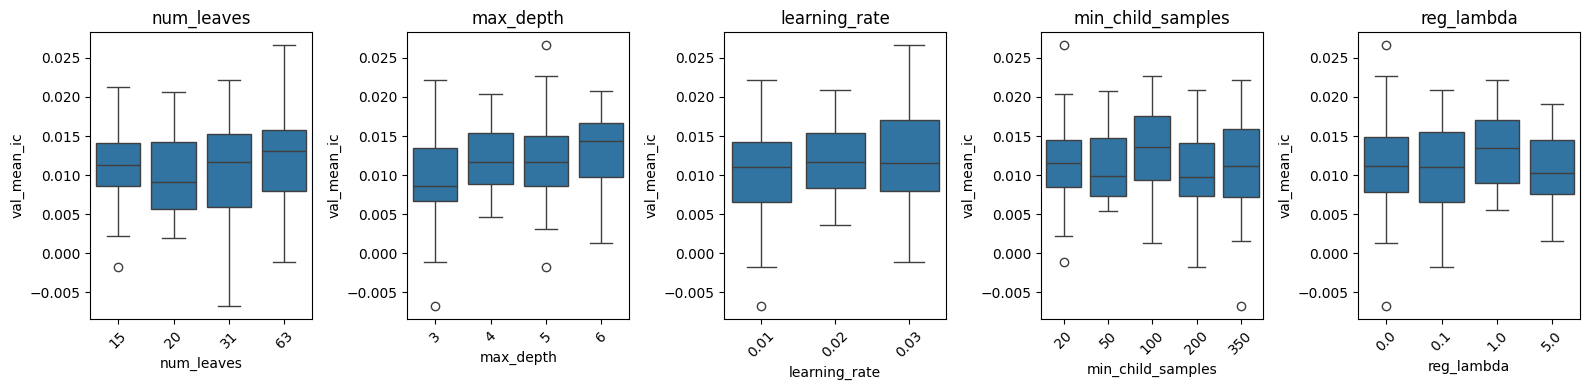

In [7]:
params_to_plot = [
    "num_leaves",
    "max_depth",
    "learning_rate",
    "min_child_samples",
    "reg_lambda",
]
fig, axes = plt.subplots(1, len(params_to_plot), figsize=(3.2 * len(params_to_plot), 4))
for ax, col in zip(axes, params_to_plot):
    sns.boxplot(data=search_df, x=col, y="val_mean_ic", ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
plt.show()

## 5. Training

Final HPs come from the search winner (`BEST_PARAMS`) — do not hand-edit.

In [8]:
print("Final HP from BEST_PARAMS:")
for k, v in BEST_PARAMS.items():
    print(f"  {k}={v}")

model = fit_lambdarank(train_df, val_df, FEATURE_COLS, BEST_PARAMS, verbose_eval=50)
model.save_model(IS_MODEL_PATH)
joblib.dump(
    {
        "booster": model,
        "best_params": BEST_PARAMS,
        "params_source": "search",
        "feature_cols": FEATURE_COLS,
    },
    IS_JOBLIB_PATH,
)
print(f"Model saved. Best iteration: {model.best_iteration}")
print(f"  txt:    {IS_MODEL_PATH}")
print(f"  joblib: {IS_JOBLIB_PATH}")

Final HP from BEST_PARAMS:
  max_depth=5
  num_leaves=63
  learning_rate=0.03
  min_child_samples=20
  subsample=0.7627620691664698
  colsample_bytree=0.7301598792637071
  reg_lambda=0.0
[50]	valid's ndcg@5: 0.407734
[100]	valid's ndcg@5: 0.426676
[150]	valid's ndcg@5: 0.429864
[200]	valid's ndcg@5: 0.435855
[250]	valid's ndcg@5: 0.436522
Model saved. Best iteration: 189
  txt:    c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_lgbm_lambdarank_is.txt
  joblib: c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_lgbm_lambdarank_is.joblib


In [9]:
preds = predict_scores(model, df, FEATURE_COLS)
if "feature_date" in df.columns:
    preds = preds.merge(
        df[["date", "ticker", "feature_date"]],
        on=["date", "ticker"],
        how="left",
    )
preds.to_parquet(PRED_PATH, index=False)
print(f"Saved predictions: {PRED_PATH}")
print(
    f"  rows={len(preds):,}  IS={preds['is_research_is'].sum():,}  "
    f"non-IS={(~preds['is_research_is']).sum():,}"
)

ho_preds = preds.loc[(~preds["is_research_is"]) & (preds["date"] > is_end)].copy()
ho_sm = mean_date_ic(ho_preds)
print(
    f"Holdout IC (IS-only model): mean={ho_sm['mean_ic']:.4f}  "
    f"ICIR={ho_sm['icir']:.3f}  n_dates={ho_sm['n']}"
)
preds.head()

Saved predictions: c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_lgbm_lambdarank_is_predictions.parquet
  rows=85,179  IS=41,522  non-IS=43,657
Holdout IC (IS-only model): mean=0.0172  ICIR=0.084  n_dates=181


,date,ticker,fwd_ret_5,is_research_is,score,cs_rank,feature_date
0,2010-01-05,AAPL,-0.025210,False,-0.313149,0.510,2010-01-04
1,2010-01-05,ABT,0.013402,False,-0.311757,0.530,2010-01-04
2,2010-01-05,ADBE,-0.024298,False,-0.268981,0.880,2010-01-04
3,2010-01-05,AET,-0.009411,False,-0.393536,0.205,2010-01-04
4,2010-01-05,AIG,-0.013009,False,-0.283115,0.790,2010-01-04


In [10]:
# Production model: IS train + post-IS holdout, early-stop on same IS val window.
# Live only -- do NOT use for holdout metrics.
prod_train = pd.concat(
    [df.loc[df["date"].isin(train_dates)], holdout_df],
    axis=0,
).sort_values(["date", "ticker"])

model_prod = fit_lambdarank(prod_train, val_df, FEATURE_COLS, BEST_PARAMS)
model_prod.save_model(PROD_MODEL_PATH)
print(
    f"Saved production model (live only): {PROD_MODEL_PATH}\n"
    f"  best_iteration={model_prod.best_iteration}  "
    f"trained on IS-train + holdout (val unused for metrics rewrite)"
)

Saved production model (live only): c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\model_artifacts\s1_lgbm_lambdarank_production.txt
  best_iteration=206  trained on IS-train + holdout (val unused for metrics rewrite)


## 6. Evaluation

Four-row IC table is the primary comparison to `training_gbm_rmse` and `training_linear_baseline`.


,mean_ic,icir,n_dates
segment,,,
IS train,0.134749,0.692150,358
IS val,0.026590,0.108695,63
IS train+val,0.118563,0.574833,421
OS holdout,0.017173,0.084179,181


IS train+val IC=0.1186 ICIR=0.575  |  OS holdout IC=0.0172 ICIR=0.084


,gain
near_52w_ratio_252_raw,867.576886
log_mcap,837.688971
upside_beta_42,620.830783
size_mom_126,619.003985
beta_mkt_interact,606.958164
smart_beta_hml_252,597.559168
downside_beta_42,480.157306
smart_beta_smb_84,467.116851
market_corr,449.762037
filing_clock_expected_until,447.707276


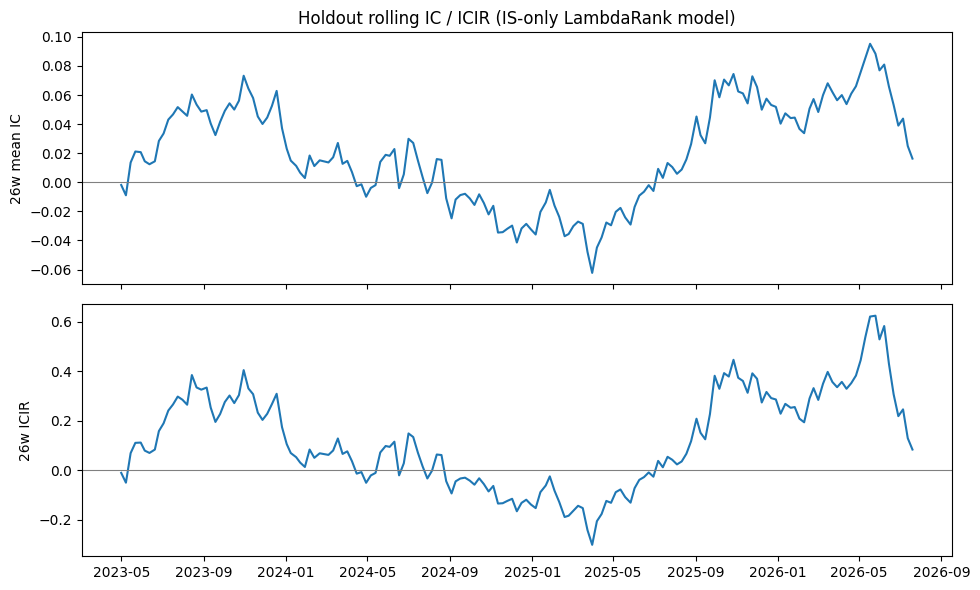

In [11]:
ic_compare = ic_segment_table(preds, train_dates, val_dates, is_end)
display(ic_compare)

tv = ic_compare.loc["IS train+val"]
ho = ic_compare.loc["OS holdout"]
print(
    f"IS train+val IC={tv['mean_ic']:.4f} ICIR={tv['icir']:.3f}  |  "
    f"OS holdout IC={ho['mean_ic']:.4f} ICIR={ho['icir']:.3f}"
)

ho_ics = date_ic_series(ho_preds).dropna().sort_index()
_min_roll = max(8, ROLLING_IC_WEEKS // 2)
roll_ic = ho_ics.rolling(ROLLING_IC_WEEKS, min_periods=_min_roll).mean()
roll_std = ho_ics.rolling(ROLLING_IC_WEEKS, min_periods=_min_roll).std()
roll_icir = roll_ic / roll_std.clip(lower=1e-6)

importance = (
    pd.Series(model.feature_importance(importance_type="gain"), index=FEATURE_COLS)
    .sort_values(ascending=False)
    .rename("gain")
)
display(importance.head(15).to_frame())

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(roll_ic.index, roll_ic.values)
axes[0].axhline(0.0, color="gray", lw=0.8)
axes[0].set_ylabel(f"{ROLLING_IC_WEEKS}w mean IC")
axes[0].set_title("Holdout rolling IC / ICIR (IS-only LambdaRank model)")
axes[1].plot(roll_icir.index, roll_icir.values)
axes[1].axhline(0.0, color="gray", lw=0.8)
axes[1].set_ylabel(f"{ROLLING_IC_WEEKS}w ICIR")
fig.tight_layout()
plt.show()